# 🛍 Customer Segmentation using K-Means & Hierarchical Clustering

## 📖 Introduction
Understanding customer behavior is essential for modern businesses. By segmenting customers into meaningful groups, companies can optimize marketing strategies, improve retention, and increase profitability.

This project applies unsupervised learning techniques to uncover hidden customer segments.

## 📊 Hierarchical Clustering Insights

- Provides deeper understanding of customer relationships
- Shows how clusters are formed step-by-step
- Helps validate K-Means results

### 💡 Business Value:
- Useful for strategic decision-making
- Helps design long-term customer segmentation strategies
- Provides explainability for stakeholders

## ⚖️ K-Means vs Hierarchical (Business Perspective)

| Aspect | K-Means | Hierarchical |
|------|--------|-------------|
| Speed | Fast | Slow |
| Scalability | High | Low |
| Use Case | Production | Analysis |
| Flexibility | Low | High |
| Output | Clusters | Dendrogram |

---

## 🚀 Final Recommendation

- Use **Hierarchical Clustering** to explore and understand the data
- Use **K-Means** to deploy scalable solutions in production

👉 This combination provides both **insight + performance**

## ❗ Problem Statement

Retail businesses often lack visibility into customer behavior patterns.

Without segmentation:
- Marketing efforts are inefficient
- High-value customers are not prioritized
- Revenue opportunities are missed

This project aims to solve this by grouping customers into meaningful clusters.

Import **Libraries**


In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Settings
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

Load Datase

In [15]:
# Load dataset
import os

# Define the file path
file_path = "Mall_Customers.csv"

# Check if the file already exists, if not, download it
if not os.path.exists(file_path):
    print("Downloading Mall_Customers.csv...")
    !wget -q https://raw.githubusercontent.com/reddyprasade/Customer-Segmentation-using-K-Means-Clustering/master/Mall_Customers.csv
    print("Download complete.")
else:
    print("Mall_Customers.csv already exists.")

df = pd.read_csv(file_path)

df.head()

Mall_Customers.csv already exists.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Data Overview

In [16]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [17]:
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

## 📊 Exploratory Data Analysis

EDA helps us:
- Understand distributions
- Detect patterns
- Identify relationships

This step is critical before applying machine learning models.

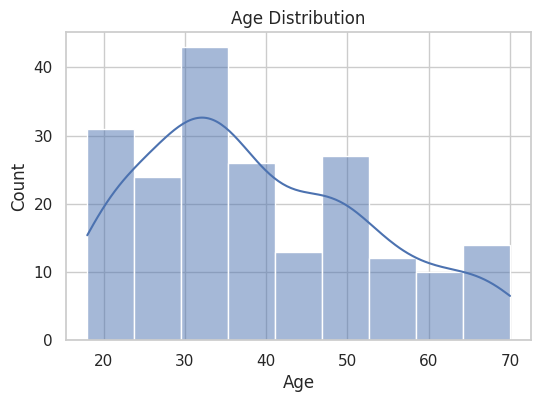

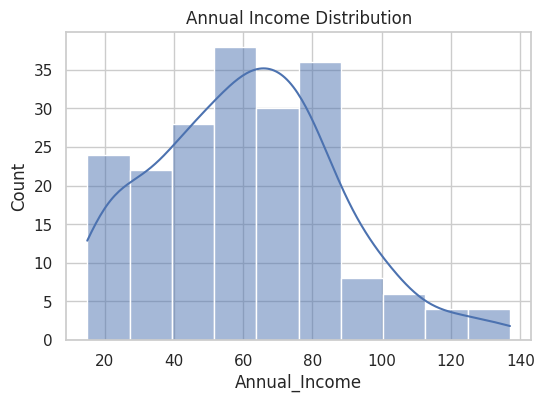

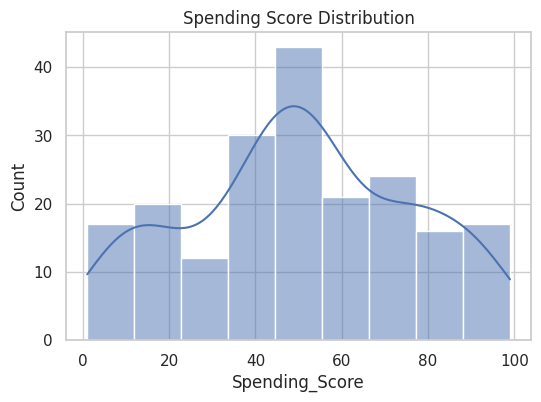

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['Annual_Income'], kde=True)
plt.title("Annual Income Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['Spending_Score'], kde=True)
plt.title("Spending Score Distribution")
plt.show()

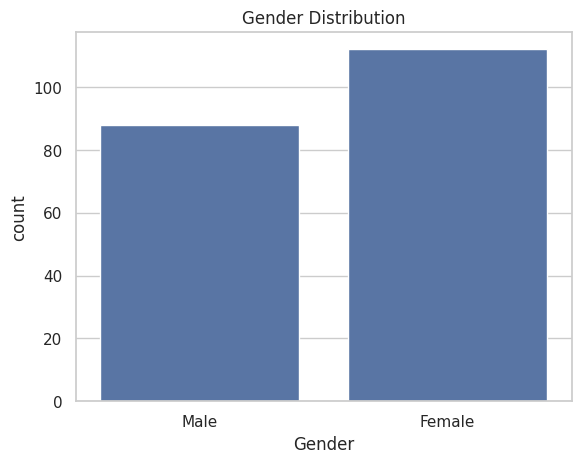

In [19]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

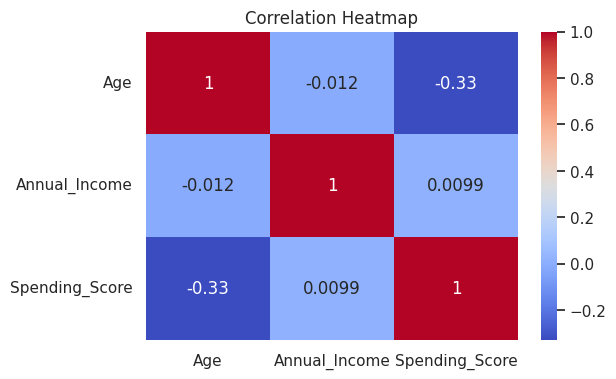

In [20]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Age','Annual_Income','Spending_Score']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## 🔍 Feature Selection

We focus on:
- Annual Income
- Spending Score

These variables directly represent customer value and behavior.

In [21]:
features = df[['Annual_Income', 'Spending_Score']]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

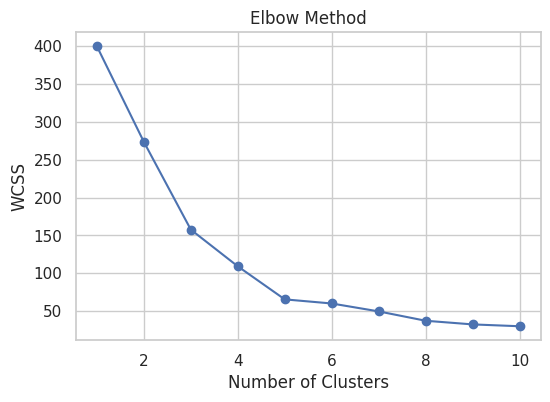

In [22]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

## 🔍 Feature Selection

We focus on:
- Annual Income
- Spending Score

These variables directly represent customer value and behavior.

## ⚙️ Feature Scaling

Clustering algorithms are distance-based.

Scaling ensures:
- Equal importance of features
- Better model performance

👉 Optimal clusters ≈ **5**

💡 Insight:
The “elbow point” indicates the optimal number of clusters, balancing accuracy and simplicity.

## 🔵 K-Means Clustering (Production-Focused Model)

### 📌 Concept
K-Means is an unsupervised machine learning algorithm that groups data into **K predefined clusters** based on similarity.

It works by minimizing the distance between data points and their cluster centroid.

---

### ⚙️ Why We Use K-Means in This Project
- Fast and efficient
- Scales well to large datasets
- Ideal for real-world business applications

---

### 💼 Business Perspective
K-Means is widely used in production systems because:

✅ Faster → Works well with large customer datasets  
✅ Scalable → Can handle millions of records  
✅ Real-time segmentation → Useful for dynamic customer targeting  

---

### 🧠 Simple Analogy
Imagine a shopping mall manager quickly grouping customers into:
- High spenders
- Average customers
- Low spenders

This helps in making quick marketing decisions.

In [33]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data) # Fit K-Means model and assign cluster labels

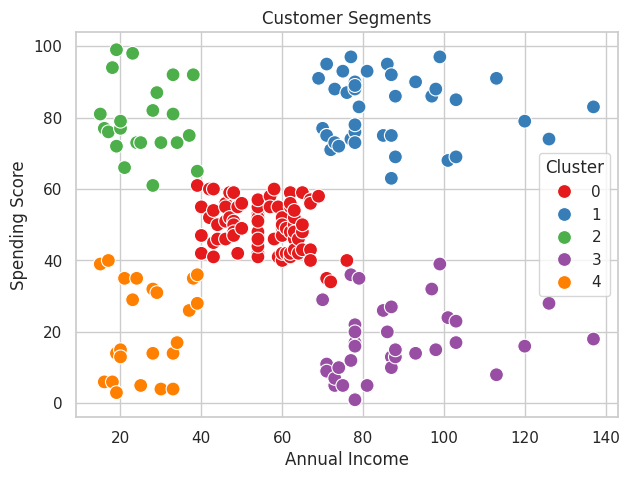

In [24]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df['Annual_Income'],
    y=df['Spending_Score'],
    hue=df['Cluster'],
    palette='Set1',
    s=100
)

plt.title("Customer Segments")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend(title="Cluster")
plt.show()

In [25]:
cluster_summary = df.groupby('Cluster')[['Age','Annual_Income','Spending_Score']].mean()
cluster_summary

,Age,Annual_Income,Spending_Score
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


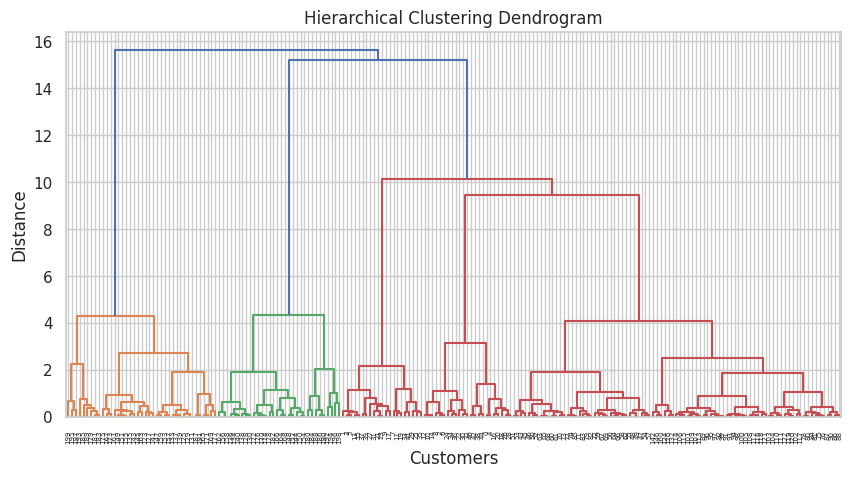

In [26]:
linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [28]:
# Select features
features = df[['Annual_Income', 'Spending_Score']]

# Scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

# Apply K-Means
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(scaled_data)

# View results
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster,KMeans_Cluster
0,1,Male,19,15,39,4,4
1,2,Male,21,15,81,2,2
2,3,Female,20,16,6,4,4
3,4,Female,23,16,77,2,2
4,5,Female,31,17,40,4,4


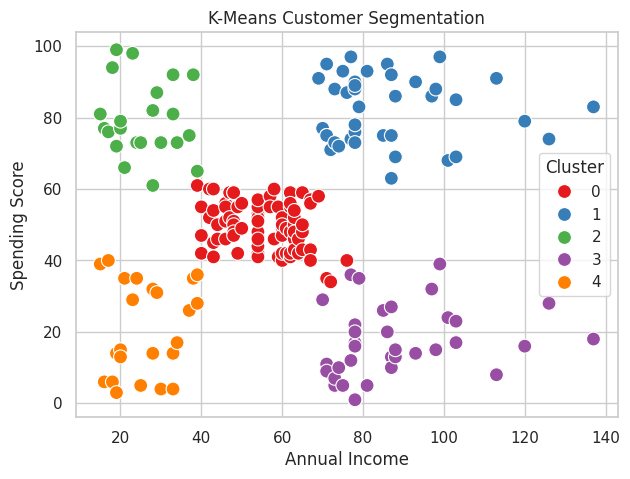

In [29]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df['Annual_Income'],
    y=df['Spending_Score'],
    hue=df['KMeans_Cluster'],
    palette='Set1',
    s=100
)

plt.title("K-Means Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend(title="Cluster")
plt.show()

## 📊 K-Means Business Insights

- Identified high-value customers
- Found low-engagement segments

### 💼 Business Impact:
- Enables targeted marketing
- Improves customer retention
- Increases revenue efficiency

## 🌳 Hierarchical Clustering (Analysis-Focused Model)

### 📌 Concept
Hierarchical clustering builds a tree-like structure (dendrogram) showing how data points are grouped step-by-step.

Unlike K-Means, it does NOT require specifying the number of clusters in advance.

---

### ⚙️ Why We Use Hierarchical Clustering
- Helps understand relationships between customers
- Useful for exploratory data analysis

---

### 💼 Business Perspective

Hierarchical clustering is valuable because:

✅ Better for analysis & understanding  
✅ Reveals hidden structure in data  
✅ Used in research and strategic planning  

---

### 🧠 Simple Analogy
Imagine organizing customers step-by-step:
- First group very similar customers
- Then merge groups gradually

This helps understand how customers relate to each other.

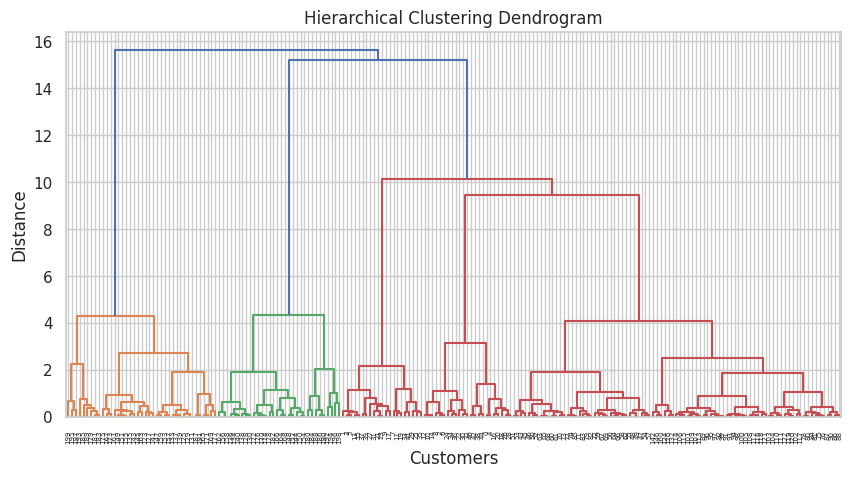

In [30]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Create linkage matrix
linked = linkage(scaled_data, method='ward')

# Plot dendrogram
plt.figure(figsize=(10,5))
dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [34]:
from scipy.cluster.hierarchy import fcluster

# Create clusters (choose number based on dendrogram)
df['Hierarchical_Cluster'] = fcluster(linked, t=5, criterion='maxclust') # Assign cluster labels based on dendrogram structure

df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster,KMeans_Cluster,Hierarchical_Cluster
0,1,Male,19,15,39,4,4,4
1,2,Male,21,15,81,2,2,3
2,3,Female,20,16,6,4,4,4
3,4,Female,23,16,77,2,2,3
4,5,Female,31,17,40,4,4,4


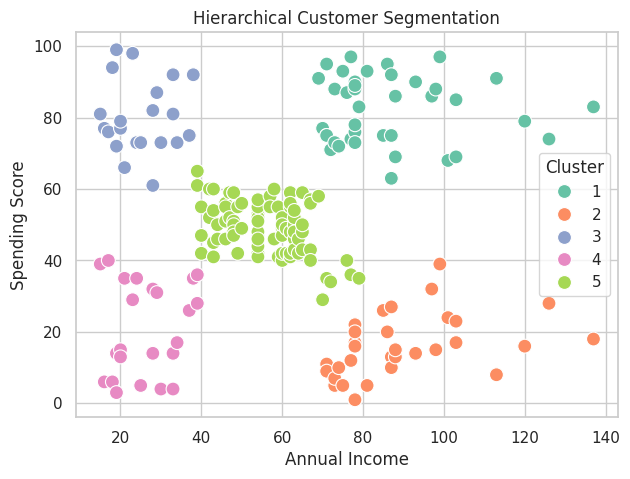

In [32]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df['Annual_Income'],
    y=df['Spending_Score'],
    hue=df['Hierarchical_Cluster'],
    palette='Set2',
    s=100
)

plt.title("Hierarchical Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend(title="Cluster")
plt.show()

## 📊 Hierarchical Insights

- Provides deeper understanding of cluster relationships
- Helps validate model results

### 💼 Business Value:
- Useful for strategic planning
- Supports decision-making transparency

## ⚖️ K-Means vs Hierarchical

| Aspect | K-Means | Hierarchical |
|------|--------|-------------|
| Speed | Fast | Slow |
| Use Case | Production | Analysis |
| Scalability | High | Low |

---

## 🚀 Recommendation

Use:
- Hierarchical → for understanding
- K-Means → for deployment

## ✅ Conclusion

This project successfully segmented customers into meaningful groups.

### 🎯 Key Outcomes:
- Identified high-value customers
- Improved understanding of customer behavior
- Enabled data-driven business decisions

## 🧠 Final Business Insights

- Premium customers drive most revenue
- Mid-level customers need retention strategies
- Low-value customers require cost-efficient engagement

### 💼 Strategic Impact:
- Personalized marketing
- Better resource allocation
- Increased profitability